### Load and Modify Configuration File

In [1]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
g : 9.81
l : 1
theta0 : 100
omega0 : 0
T : 7
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : tanh
N_epochs : 20000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularizer : unstable_fp
reg_coeff : 100000
reg_decay : 1
reg_epochs : 1


### Initialize Physics-Informed Neural Network

In [2]:
from model.neural_net import PhysicsInformedNN
PINN = PhysicsInformedNN(config, verbose=True)

2024-11-01 18:10:02.929239: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-01 18:10:02.990571: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-01 18:10:02.991410: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-01 18:10:03.926095: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Model: "PhysicsInformedNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                100       
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dense_2 (Dense)             (None, 50)                2550      
                                                                 
 dense_3 (Dense)             (None, 50)                2550      
                                                                 
 dense_4 (Dense)             (None, 1)                 51        
                                                                 
Total params: 7801 (30.47 KB)
Trainable params: 7801 (30.47 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
*** PINN build 

### Train Physics-Informed Neural Network

In [3]:
training_log = PINN.train()

Training started...
    0/20000 | loss_P: 9.93e+05 | loss_IC: 3.25e+00
 1000/20000 | loss_P: 2.22e+01 | loss_IC: 9.06e+00
 2000/20000 | loss_P: 9.52e+00 | loss_IC: 6.64e+00
 3000/20000 | loss_P: 7.40e+00 | loss_IC: 5.50e+00
 4000/20000 | loss_P: 4.96e+00 | loss_IC: 4.14e+00
 5000/20000 | loss_P: 2.50e+00 | loss_IC: 2.93e+00
 6000/20000 | loss_P: 1.24e+00 | loss_IC: 2.23e+00
 7000/20000 | loss_P: 4.73e-01 | loss_IC: 1.89e+00
 8000/20000 | loss_P: 2.69e-01 | loss_IC: 1.75e+00
 9000/20000 | loss_P: 1.62e-01 | loss_IC: 1.70e+00
10000/20000 | loss_P: 1.06e-01 | loss_IC: 1.66e+00
11000/20000 | loss_P: 1.54e-01 | loss_IC: 1.62e+00
12000/20000 | loss_P: 1.71e-01 | loss_IC: 1.59e+00
13000/20000 | loss_P: 1.52e-01 | loss_IC: 1.56e+00
14000/20000 | loss_P: 1.68e-01 | loss_IC: 1.48e+00
15000/20000 | loss_P: 3.10e-01 | loss_IC: 1.14e+00
16000/20000 | loss_P: 3.80e-01 | loss_IC: 8.53e-01
17000/20000 | loss_P: 5.08e-01 | loss_IC: 5.95e-01
18000/20000 | loss_P: 5.61e-01 | loss_IC: 5.37e-01
19000/20000

# Plot Section

In [4]:
from model.plots import learning_curves, pendulum_dynamics, loss_over_tcoll, plot_regularization, results_heatmap

### Learning Curves

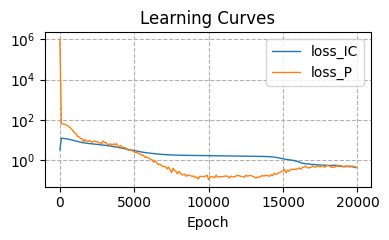

In [5]:
learning_curves(training_log)

### Pendulum Dynamics

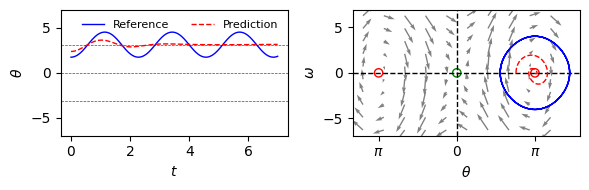

In [6]:
pendulum_dynamics(PINN)

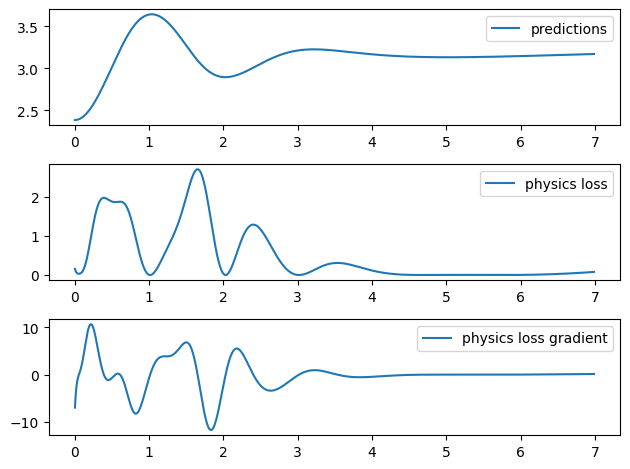

In [7]:
loss_over_tcoll(PINN)

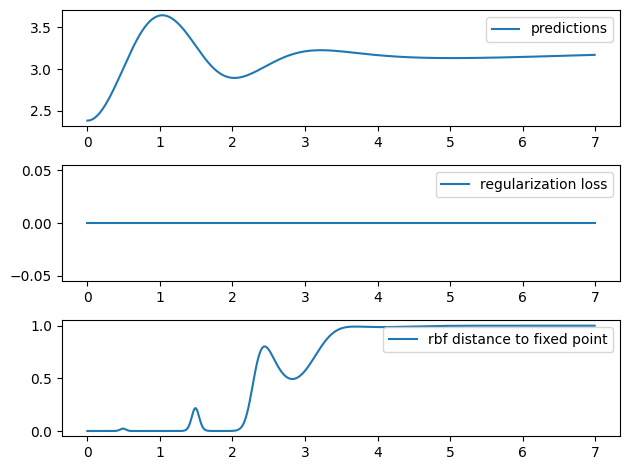

In [8]:
plot_regularization(PINN)

### Training animation

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML



def init_fig():

    fig, ax = plt.subplots()

    #############################
    ### Initial plot comes here
    #############################

    plt.tight_layout()
    plt.close(fig)
    return fig, ax


def animate(i, *fargs):
    # get passed arguments
    ax = fargs[0]
    N_times = fargs[1]

    # print status of animation
    print(f'Processed: {i/N_times*100:.0f}%', end='\r')

    # clear axis
    ax.clear()
    #############################
    ### load model weights & make predictions
    #############################
    flag = i * config['freq_save']
    PINN.load_weights(PINN.log_path.joinpath(f'model_weights/weights_{flag}.pkl'))

    ############################
    # Prediciton plot
    ############################

    # stable/unstable fixed points
    line_props = {'ls': '--', 'lw': 0.5}
    ax.axhline(0, c='green', **line_props)
    ax.axhline(np.pi, c='red', **line_props)
    ax.axhline(-np.pi, c='red', **line_props)

    # Reference data and PINN prediction
    t_line, theta_true, omega_true = PINN.data.reference()
    theta_pred = PINN(t_line)
    
    ##############################
    ### Regularization coefficient
    ##############################
    epoch = flag
    coeff = config["reg_coeff"] * (float(config["reg_decay"])**epoch)
    if epoch > (config["reg_epochs"] * config["N_epochs"]):
        coeff = 0
    
    ax.plot([], [], c='black', lw=1, label=f'regularization coeff {coeff}')
           
    #############################
    ### Updated plot comes here
    #############################

    # make plot
    ax.plot(t_line, theta_true, c='blue', lw=1, label='Reference')
    ax.plot(t_line, theta_pred, c='red', lw=1, ls='--', label='Prediction')

    # Axis appearance
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$\theta$')
    ax.legend(frameon=False, loc=1, ncol=2, fontsize=8)
    ax.set_ylim([-3.5, 3.5])
    


    plt.tight_layout()


# should equal the number of saved weights files
N_frames = int(config["N_epochs"] / config["freq_save"])

(fig, ax) = init_fig()
ani = FuncAnimation(fig, animate, frames=N_frames, fargs=(ax, N_frames))
HTML(ani.to_jshtml())

<Figure size 640x480 with 0 Axes>

2024-11-14 12:07:55.498319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1731582475.514138   21554 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1731582475.518857   21554 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-14 12:07:55.533461: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


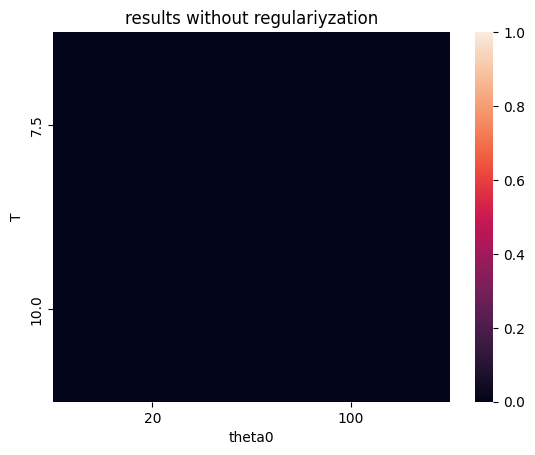

/home/mbabic/Desktop/PINNs_fixed_points/inverted_undamped_pendulum_a/model/plots.py:180: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  results["reg_decay"].fillna("no decay", inplace=True)
/home/mbabic/Desktop/PINNs_fixed_points/inverted_undamped_pendulum_a/model/plots.py:180: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'no decay' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results["reg_decay"].fil

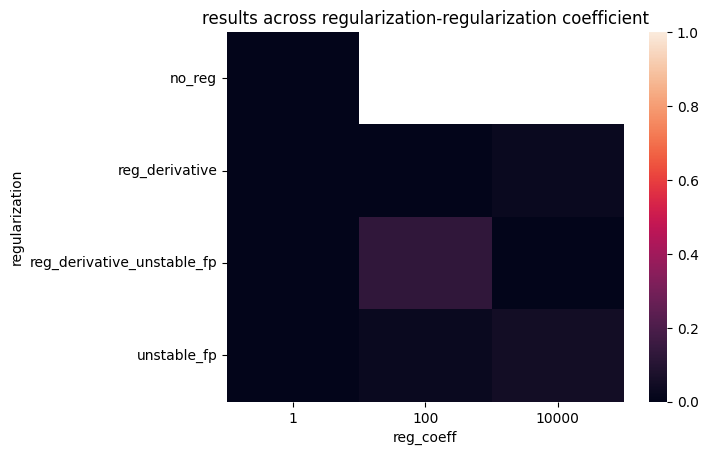

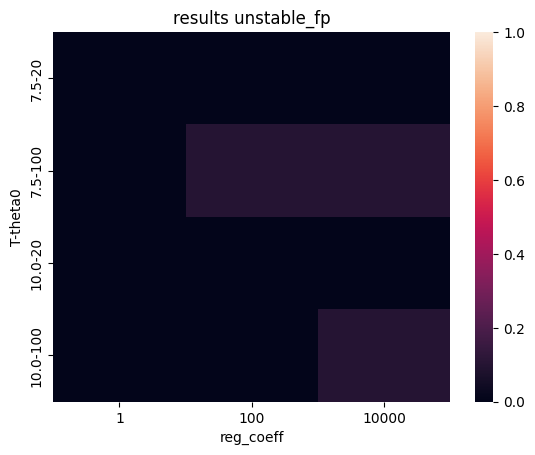

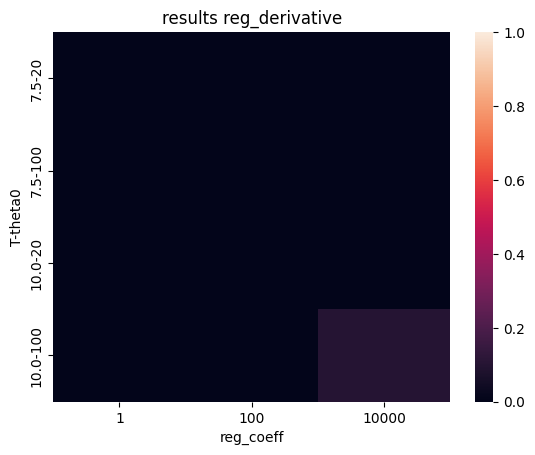

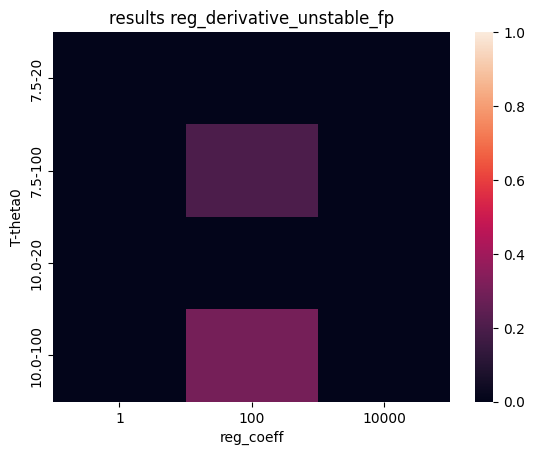

In [1]:
import pandas as pd
import numpy as np
from model.plots import results_heatmaps

results = pd.read_csv("results_a.csv")

results_heatmaps(results)

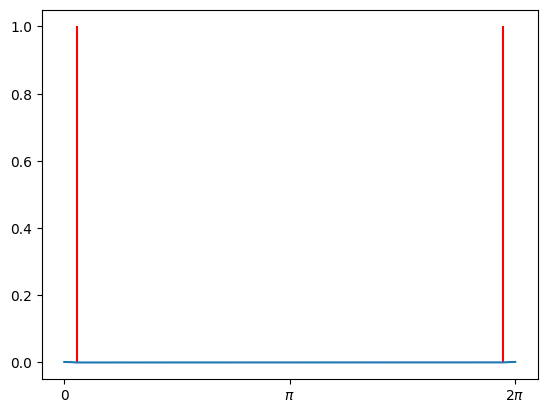

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

l = 1
g = 9.81

theta = np.linspace(0, 2*np.pi, 1000)
theta0 = np.radians(10)
a = theta0

reg_loss = tf.nn.relu((np.cos(theta) - np.cos(a)) * l / g)
plt.plot(theta, reg_loss)
plt.xticks([0, np.pi, 2*np.pi], labels=[0, r'$\pi$', r'$2\pi$'])
plt.vlines([theta0, 2 * np.pi - theta0], ymin=0, ymax=1, colors=["r"])
plt.show()